# **Fake News Detection Model Training**

This notebook creates a BERT-based machine learning model designed to predict whether a news article is fake or real. The notebook follows the same structure as the sentiment analysis training but adapted for fake news classification.

The input file should be formatted with the following:
1. An "Article" column containing the news text
2. A "Truth" column with 0 (fake) or 1 (real)

### Preparing Tools and Files

In [ ]:
# ! pip install torch
# ! pip install transformers
# ! pip install numpy
# ! pip install pandas
# ! pip install datasets

In [77]:
import torch, numpy as np, pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, get_scheduler
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import tqdm
from datasets import Dataset

In [78]:
# Load the reduced/cleaned fake news dataset
df = pd.read_csv('../data/processed/01/reduced_dataset.csv')
df.head()

,Article,Truth,Source
0,celebrities join tax march protest donald trum...,0,gossipcop
1,heres really happened jfk jr met princess dian...,0,gossipcop
2,angelina jolie cant get heartbreak losing brad...,0,gossipcop
3,oscar nominations 2018 complete list oscar nom...,0,gossipcop
4,hes hired ben affleck enlists best friend matt...,0,gossipcop


### Preprocessing

The goal of preprocessing is to turn human-readable data into computer-readable training data.

First, we will check the dataset for missing parameters and remove them. We'll also allow you to select how much of the dataset you want to use for training.

In [79]:
df.isna().sum()

# Check class distribution
print("Class distribution:")
print(df['Truth'].value_counts())

Class distribution:
Truth
1    32232
0    26269
Name: count, dtype: int64


Now, we're going to trim down this dataset. Choose how many samples you want to use for training:

In [80]:
# 🎛️ DATASET SIZE SELECTOR - Choose how much data to train on
# Options: 1000 (fast), 5000 (medium), 10000 (slower), or len(df) (full dataset)
DATASET_SIZE = 1000  # Change this number to control training size and speed

print(f"Full dataset size: {len(df)}")

# Get balanced sample with equal fake and real news
fake_news = df[df['Truth'] == 0].head(DATASET_SIZE // 2)
real_news = df[df['Truth'] == 1].head(DATASET_SIZE // 2)
df = pd.concat([fake_news, real_news]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Selected dataset size: {len(df)}")

# Check balance after reduction
print(f"\nClass balance after reduction:")
print(df['Truth'].value_counts())

Full dataset size: 58501
Selected dataset size: 1000

Class balance after reduction:
Truth
1    500
0    500
Name: count, dtype: int64


Next, we'll tokenize the words. This takes the words and turns them into "tokens", chunks of information that can be read and understood by the computer.

In [81]:
# Create HuggingFace dataset
dataset = Dataset.from_pandas(df)

# Rename Truth column to labels (required by BERT model)
dataset = dataset.rename_column("Truth", "labels")

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["Article"], padding=True, truncation=True, max_length=128)

# Apply tokenizer
dataset_enc = dataset.map(tokenize, batched=True, remove_columns=["Article", "Source"])
dataset_enc = dataset_enc.train_test_split(test_size=0.2)

Map: 100%|██████████| 1000/1000 [00:00<00:00, 5976.40 examples/s]


Next, we want to convert these to pytorch tensors, objects that can be read by the pytorch library.

In [82]:
dataset_enc.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

The last few tools are the dataloaders and collators.

* The dataloaders will make sure we're sending small batches of articles/labels. The training data will be shuffled, making sure that the model isn't training for unintended patterns.

* The collator helps with efficiency of space and time by increasing the size of all tokens to the largest token in the batch.

In [83]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [84]:
# Dataloaders
train_dataloader = DataLoader(
    dataset_enc["train"], shuffle=True, batch_size=8, collate_fn=data_collator
)
eval_dataloader = DataLoader(
    dataset_enc["test"], batch_size=5, collate_fn=data_collator
)

## Processing

First we load the model to be trained.

In [85]:
num_labels = 2 # fake and real, or 0 and 1
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=num_labels
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Now let's define some parameters for how the model will train.

* learning rate: how much the model will adjust its weights based on error.

* epochs: how many times the model will go through the entire dataset.

**Training is made up of epochs, epochs are made up of batches, batches are made up of entries.**

In [94]:
learning_rate = 5e-5
num_epochs = 3

We'll set up a dynamic learning rate, shrinking over time as we get closer. Our first few runs will be rough, but as it gets better at prediction (lower loss), we want our adjustments to be smaller with it.

In [95]:
optimizer = AdamW(model.parameters(), lr=learning_rate)
num_training_batches = len(train_dataloader)
num_training_steps = num_epochs * num_training_batches
lr_scheduler = get_scheduler("linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

Now we specify which part of the computer will process this. We'll use CPU to avoid GPU memory issues and ensure stable training.

In [96]:
device = torch.device("cpu")  # Use CPU for stable training
model.to(device)
progress_bar = tqdm(range(num_training_steps)) # for convenience
model.train()

  6%|▌         | 22/400 [01:14<21:25,  3.40s/it]


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

Training Loop:

Epoch 1 of 3


 33%|███▎      | 100/300 [03:14<06:22,  1.91s/it]

Average Loss: 0.6553
Epoch 2 of 3


 67%|██████▋   | 200/300 [06:29<03:15,  1.95s/it]

Average Loss: 0.4866
Epoch 3 of 3


100%|██████████| 300/300 [09:45<00:00,  1.92s/it]

Average Loss: 0.2891


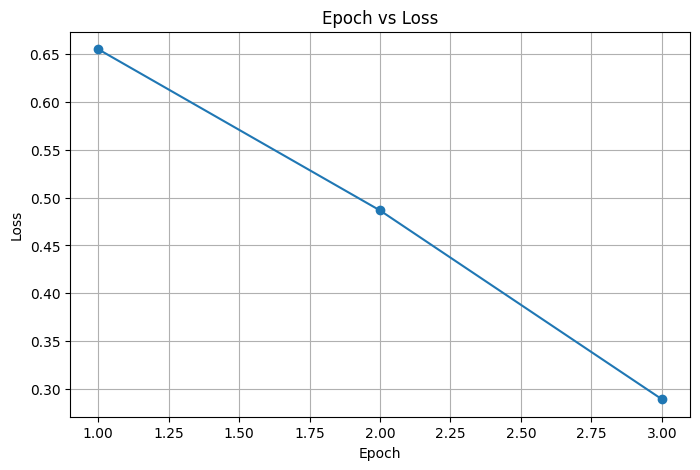

In [97]:
import matplotlib.pyplot as plt

train_losses = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1} of {num_epochs}")
    running_loss = 0.0

    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        running_loss += loss.item()
        progress_bar.update(1)

    avg_loss = running_loss / len(train_dataloader)
    train_losses.append(avg_loss)
    print(f"Average Loss: {avg_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss")
plt.grid(True)
plt.show()

To keep persistent, save the weights to a file

In [60]:
model_save_path = '../models/bert_fake_news_trained'
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

('../models/bert_fake_news_trained\\tokenizer_config.json',
 '../models/bert_fake_news_trained\\special_tokens_map.json',
 '../models/bert_fake_news_trained\\vocab.txt',
 '../models/bert_fake_news_trained\\added_tokens.json',
 '../models/bert_fake_news_trained\\tokenizer.json')